# Etape 1: CLV historique et création de la target

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [182]:
import pandas as pd

transactions = pd.read_csv("./src/transactions.csv")
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
print(transactions["invoice_date"].dtype)

datetime64[ns]


In [183]:
df_clean = transactions.copy()

# 1) Retirer les lignes sans client (indispensable TP2)
df_clean = df_clean.dropna(subset=["customer_id"])

# 2) Retirer prix négatifs / nuls
df_clean = df_clean[df_clean["unit_price"] > 0]

# 3) Retirer quantités négatives / nulles (retours, annulations)
df_clean = df_clean[df_clean["quantity"] > 0]

# 4) Retirer dates invalides
df_clean = df_clean.dropna(subset=["invoice_date"])

# 5) Retirer doublons exacts
df_clean = df_clean.drop_duplicates()

# 6) Retirer doublons métier (même facture, client, produit)
transactions= df_clean.drop_duplicates(subset=["invoice_id", "customer_id", "product_code"])

In [184]:
snapshot_date = pd.Timestamp("2008-07-01")
end_target = snapshot_date + pd.DateOffset(months=12)

obs_tx = transactions[transactions["invoice_date"] < snapshot_date]

target_tx = transactions[
    (transactions["invoice_date"] >= snapshot_date) &
    (transactions["invoice_date"] < end_target)
]
print("Min date target :", target_tx["invoice_date"].min())
print("Max date target :", target_tx["invoice_date"].max())
print("Nombre de mois :", target_tx["invoice_date"].dt.to_period("M").nunique())

Min date target : 2008-07-01 12:20:00
Max date target : 2009-06-30 12:20:00
Nombre de mois : 12


/var/folders/9q/bkb988rn7tb807xrlvs8wcnh0000gn/T/ipykernel_28325/3837589106.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  obs_tx.set_index("invoice_date").resample("M").size().plot(label="Observation")
/var/folders/9q/bkb988rn7tb807xrlvs8wcnh0000gn/T/ipykernel_28325/3837589106.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  target_tx.set_index("invoice_date").resample("M").size().plot(label="Target")


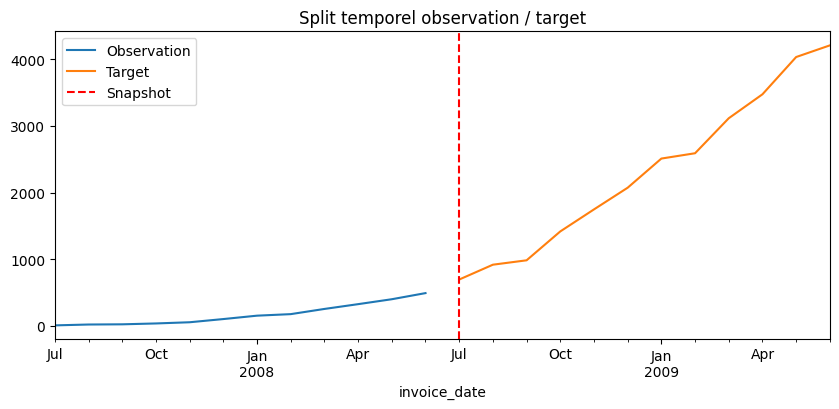

In [185]:
plt.figure(figsize=(10,4))
obs_tx.set_index("invoice_date").resample("M").size().plot(label="Observation")
target_tx.set_index("invoice_date").resample("M").size().plot(label="Target")
plt.axvline(snapshot_date, color="red", linestyle="--", label="Snapshot")
plt.legend()
plt.title("Split temporel observation / target")
plt.show()

In [186]:
target_tx["amount"] = target_tx["quantity"] * target_tx["unit_price"]

clv_target = (
    target_tx
    .groupby("customer_id")["amount"]
    .sum()
    .reset_index(name="clv_12m")
)

print(clv_target.head())

   customer_id    clv_12m
0 21467.000000 214.200000
1 21470.000000  72.000000
2 21584.000000 130.800000
3 21664.000000  20.800000
4 21812.000000   3.100000


/var/folders/9q/bkb988rn7tb807xrlvs8wcnh0000gn/T/ipykernel_28325/1364452112.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_tx["amount"] = target_tx["quantity"] * target_tx["unit_price"]


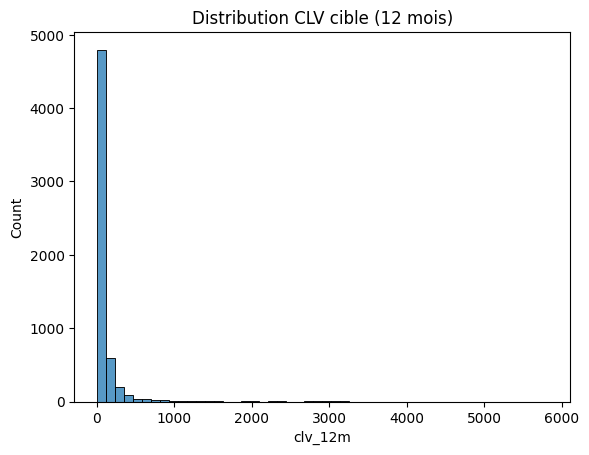

In [187]:
sns.histplot(clv_target["clv_12m"], bins=50)
plt.title("Distribution CLV cible (12 mois)")
plt.show()

# ÉTAPE 2 — Split temporel

In [188]:
obs_tx   # transactions AVANT le snapshot (période d’observation)
snapshot_date = pd.Timestamp("2008-07-01")

In [189]:
obs_tx = obs_tx.copy()

obs_tx["invoice_date"] = pd.to_datetime(obs_tx["invoice_date"])
obs_tx["amount"] = obs_tx["quantity"] * obs_tx["unit_price"]

In [190]:
rfm = (
    obs_tx
    .groupby("customer_id")
    .agg(
        recency_days = ("invoice_date", lambda x: (snapshot_date - x.max()).days),
        frequency    = ("invoice_id", "nunique"),
        monetary     = ("amount", "sum"),
        avg_basket   = ("amount", "mean")
    )
    .reset_index()
)

print(rfm.head())

   customer_id  recency_days  frequency  monetary  avg_basket
0 23236.000000            46          1 30.000000   15.000000
1 23241.000000            63          1 23.550000   11.775000
2 23259.000000            40          1 15.250000    7.625000
3 23281.000000            14          1 17.850000   17.850000
4 23293.000000           221          1 15.000000   15.000000


## FEATURES COMPORTEMENTALES

In [191]:
import numpy as np

# nombre de catégories distinctes
categories = (
    obs_tx.groupby("customer_id")["product_code"]
    .nunique()
    .reset_index(name="n_categories")
)

# régularité des achats (écart-type inter-achats)
obs_tx = obs_tx.sort_values(["customer_id", "invoice_date"])
obs_tx["prev_date"] = obs_tx.groupby("customer_id")["invoice_date"].shift(1)
obs_tx["inter_days"] = (obs_tx["invoice_date"] - obs_tx["prev_date"]).dt.days

regularity = (
    obs_tx
    .groupby("customer_id")["inter_days"]
    .std()
    .reset_index(name="interpurchase_std")
)


# proportion d’achats en mois de pic saisonnier (ex : nov-déc)
monthly_sales = (
    obs_tx
    .groupby(obs_tx["invoice_date"].dt.month)["amount"]
    .sum()
)

peak_months = monthly_sales.nlargest(3).index.tolist()

obs_tx["is_peak_month"] = obs_tx["invoice_date"].dt.month.isin(peak_months)

seasonality = (
    obs_tx
    .groupby("customer_id")["is_peak_month"]
    .mean()
    .reset_index(name="prop_peak_months")
)

# tendance de dépense
def trend_slope(df):
    if len(df) < 2:
        return 0
    x = np.arange(len(df))
    y = df["amount"].values
    return np.polyfit(x, y, 1)[0]

trend = (
    obs_tx
    .groupby("customer_id")
    .apply(trend_slope)
    .reset_index(name="amount_trend")
)

/var/folders/9q/bkb988rn7tb807xrlvs8wcnh0000gn/T/ipykernel_28325/1694253435.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  obs_tx


## FEATURES TEMPORELLES

In [192]:
temporal = (
    obs_tx
    .groupby("customer_id")
    .agg(
        tenure_days = ("invoice_date", lambda x: (snapshot_date - x.min()).days),
        first_month = ("invoice_date", lambda x: x.min().month),
        active_months = ("invoice_date", lambda x: x.dt.to_period("M").nunique()),
        frequency = ("invoice_id", "nunique")
    )
    .reset_index()
)

In [193]:
temporal["purchase_density"] = temporal["frequency"] / temporal["active_months"]

## FEATURES GÉOGRAPHIQUES

In [194]:
geo = obs_tx[["customer_id", "country"]].drop_duplicates()

geo_encoded = pd.get_dummies(
    geo,
    columns=["country"],
    drop_first=True
)

## DATASET FEATURES FINAL

In [195]:
features = (
    rfm
    .merge(categories, on="customer_id", how="left")
    .merge(regularity, on="customer_id", how="left")
    .merge(seasonality, on="customer_id", how="left")
    .merge(trend, on="customer_id", how="left")
    .merge(temporal, on="customer_id", how="left")
    .fillna(0)
)

print("Shape :", features.shape)
print(features.head())

Shape : (617, 14)
   customer_id  recency_days  frequency_x  monetary  avg_basket  n_categories  \
0 23236.000000            46            1 30.000000   15.000000             2   
1 23241.000000            63            1 23.550000   11.775000             2   
2 23259.000000            40            1 15.250000    7.625000             2   
3 23281.000000            14            1 17.850000   17.850000             1   
4 23293.000000           221            1 15.000000   15.000000             1   

   interpurchase_std  prop_peak_months  amount_trend  tenure_days  \
0           0.000000          1.000000     -0.000000           46   
1           0.000000          1.000000    -16.050000           63   
2           0.000000          1.000000      3.350000           40   
3           0.000000          1.000000      0.000000           14   
4           0.000000          0.000000      0.000000          221   

   first_month  active_months  frequency_y  purchase_density  
0            5   

In [196]:
features = (
    features
    .merge(clv_target, on="customer_id", how="left")
    .fillna({"clv_12m": 0})
)

## Étape 3 : Modélisation et évaluation

In [197]:
%pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [198]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [199]:
import numpy as np

features["clv_log"] = np.log1p(features["clv_12m"])

In [200]:
if "country" in features.columns:
    model_df = features.drop(columns=[c for c in features.columns if c.startswith("country_")], errors="ignore")

In [201]:
sort_col = "tenure_days" if "tenure_days" in features.columns else "recency_days"
features_sorted = features.sort_values(sort_col).reset_index(drop=True)

print("Split temporel basé sur :", sort_col)

Split temporel basé sur : tenure_days


In [202]:
split_idx = int(len(features_sorted) * 0.8)

train = features_sorted.iloc[:split_idx].copy()
test  = features_sorted.iloc[split_idx:].copy()

print("Train shape :", train.shape)
print("Test shape  :", test.shape)

Train shape : (493, 16)
Test shape  : (124, 16)


In [203]:
X_train = train.drop(columns=["clv_12m", "clv_log"], errors="ignore")
y_train = train["clv_log"]

X_test  = test.drop(columns=["clv_12m", "clv_log"], errors="ignore")
y_test  = test["clv_log"]

X_train.head()

,customer_id,recency_days,frequency_x,monetary,avg_basket,n_categories,interpurchase_std,prop_peak_months,amount_trend,tenure_days,first_month,active_months,frequency_y,purchase_density
0,53778.000000,0,1,64.950000,16.237500,4,0.000000,1.000000,-1.905000,0,6,1,1,1.000000
1,48702.000000,0,1,14.850000,14.850000,1,0.000000,1.000000,0.000000,0,6,1,1,1.000000
2,31628.000000,0,1,29.750000,29.750000,1,0.000000,1.000000,0.000000,0,6,1,1,1.000000
3,32192.000000,0,1,32.460000,8.115000,4,0.000000,1.000000,0.226000,0,6,1,1,1.000000
4,24133.000000,1,1,19.500000,19.500000,1,0.000000,1.000000,0.000000,1,6,1,1,1.000000


In [204]:
""" #from sklearn.model_selection import train_test_split

#X = features.drop(columns=["customer_id", "clv_12m"])
#y = features["clv_12m"]

#X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("Train:", X, " Test:", y)  """

' #from sklearn.model_selection import train_test_split\n\n#X = features.drop(columns=["customer_id", "clv_12m"])\n#y = features["clv_12m"]\n\n#X_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, shuffle=False\n)\nprint("Train:", X, " Test:", y)  '

In [205]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Régression linéaire (log target)
lr = LinearRegression()
lr.fit(X_train, np.log1p(y_train))

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting (remplace XGBoost)
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [206]:
pred_lr = np.expm1(lr.predict(X_test))
pred_rf = rf.predict(X_test)
pred_gbr = gbr.predict(X_test)

results = {
    "Régression linéaire": (
        mean_absolute_error(y_test, pred_lr),
        mean_squared_error(y_test, pred_lr) ** 0.5,
        r2_score(y_test, pred_lr),
        pred_lr
    ),
    "Random Forest": (
        mean_absolute_error(y_test, pred_rf),
        mean_squared_error(y_test, pred_rf) ** 0.5,
        r2_score(y_test, pred_rf),
        pred_rf
    ),
    "Gradient Boosting": (
        mean_absolute_error(y_test, pred_gbr),
        mean_squared_error(y_test, pred_gbr) ** 0.5,
        r2_score(y_test, pred_gbr),
        pred_gbr
    )
}

/Users/prisciliagb/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/prisciliagb/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/prisciliagb/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [207]:
import pandas as pd

pd.set_option('display.float_format', '{:.6f}'.format)

In [208]:
pd.DataFrame({
    name: {"MAE": r[0], "RMSE": r[1], "R2": r[2]}
    for name, r in results.items()
}).T

,MAE,RMSE,R2
Régression linéaire,0.873714,1.243588,0.196591
Random Forest,0.501975,1.025260,0.453925
Gradient Boosting,0.907135,1.291706,0.133215


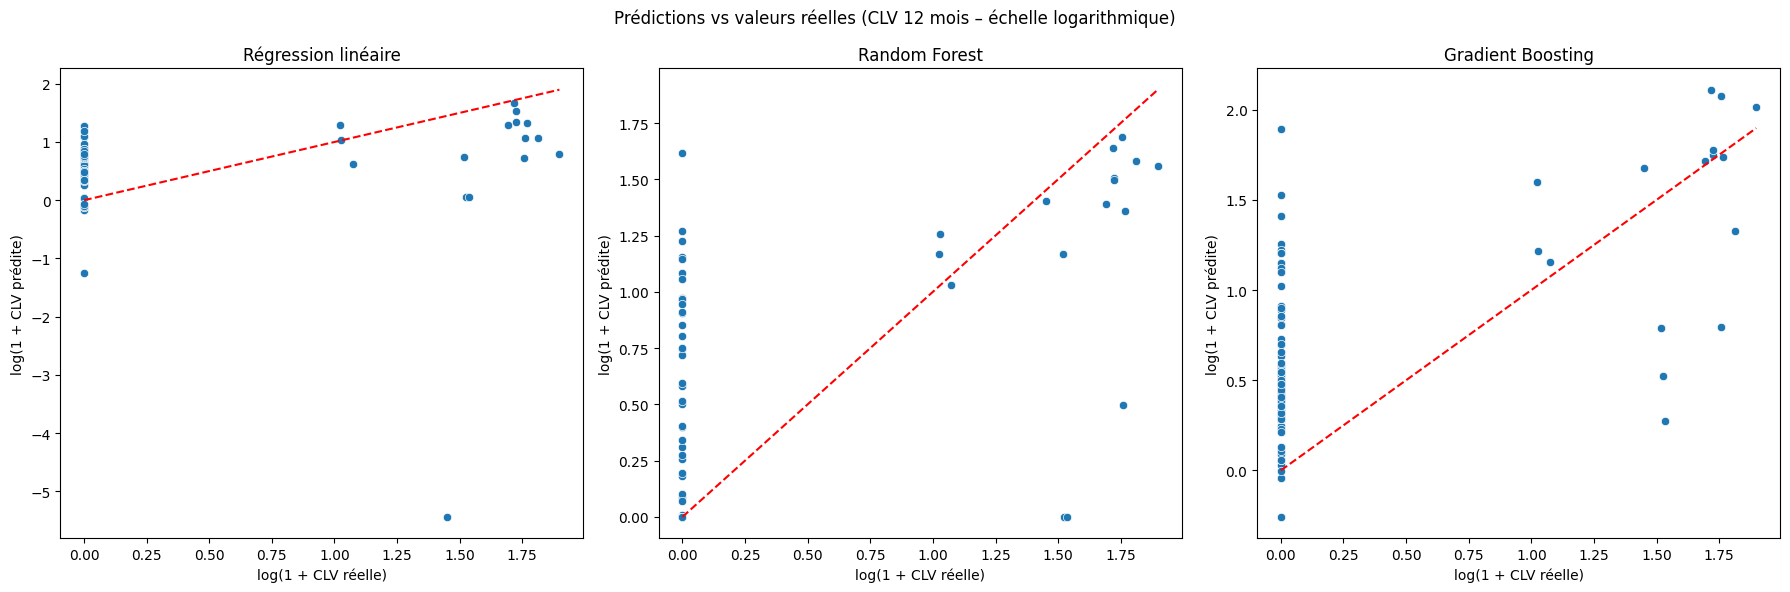

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = {
    "Régression linéaire": pred_lr,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gbr
}

for ax, (name, preds) in zip(axes, models.items()):
    sns.scatterplot(
        x=np.log1p(y_test),
        y=np.log1p(preds),
        ax=ax
    )
    max_val = np.log1p(y_test).max()
    ax.plot([0, max_val], [0, max_val], 'r--')
    ax.set_title(name)
    ax.set_xlabel("log(1 + CLV réelle)")
    ax.set_ylabel("log(1 + CLV prédite)")

plt.suptitle("Prédictions vs valeurs réelles (CLV 12 mois – échelle logarithmique)")
plt.tight_layout()
plt.show()

## Partie4


In [210]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [211]:
import shap
import numpy as np

In [212]:
X_train.dtypes.value_counts()

float64    7
int64      7
Name: count, dtype: int64

In [213]:
X_train.select_dtypes(exclude=["number"]).head()

""
0
1
2
3
4


In [214]:
# Conversion totale et définitive
X_train_num = X_train.copy()
X_test_num = X_test.copy()

for col in X_train_num.columns:
    X_train_num[col] = pd.to_numeric(X_train_num[col], errors="coerce")
    X_test_num[col] = pd.to_numeric(X_test_num[col], errors="coerce")

X_train_num = X_train_num.fillna(0)
X_test_num = X_test_num.fillna(0)

In [215]:
# Conversion des bool en int (OBLIGATOIRE POUR SHAP)
X_train_num = X_train.copy()
X_test_num = X_test.copy()

bool_cols = X_train_num.select_dtypes(include=["bool"]).columns

X_train_num[bool_cols] = X_train_num[bool_cols].astype(int)
X_test_num[bool_cols] = X_test_num[bool_cols].astype(int)

In [216]:
X_train_num.dtypes.value_counts()

float64    7
int64      7
Name: count, dtype: int64

In [217]:
X_shap = X_train_num.sample(300, random_state=42)

explainer = shap.TreeExplainer(gbr)
shap_values = explainer.shap_values(X_shap)

**Beeswarm plot — importance globale des features**

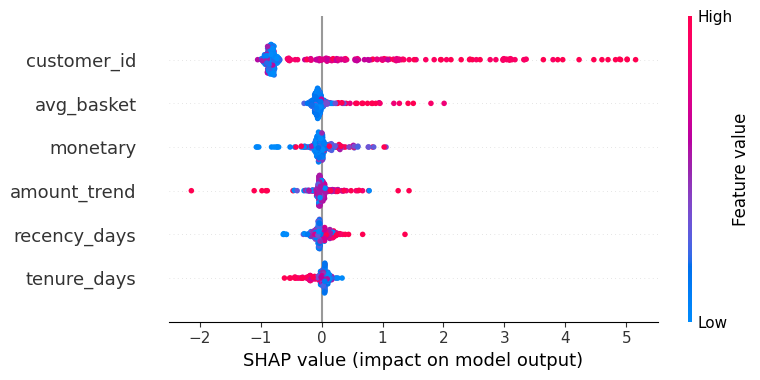

In [218]:
# Explainer sur le modèle entraîné
explainer = shap.TreeExplainer(gbr)

# SHAP values calculées sur les features complètes
shap_values = explainer.shap_values(X_shap)

# Beeswarm restreint aux features business
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    max_display=6
)

Le beeswarm plot met en évidence que les variables RFM (monetary, frequency, recency) sont les principaux moteurs de la CLV prédite. Les variables comportementales et temporelles apportent une information complémentaire permettant d’affiner la segmentation des clients.

**Client à CLV prédite élévée**

In [219]:
preds = gbr.predict(X_test)

high_idx = np.argmax(preds)
low_idx = np.argmin(preds)

X_high = X_test.iloc[[high_idx]]
X_low = X_test.iloc[[low_idx]]

In [220]:
shap_high = explainer(X_high)
shap_low = explainer(X_low)

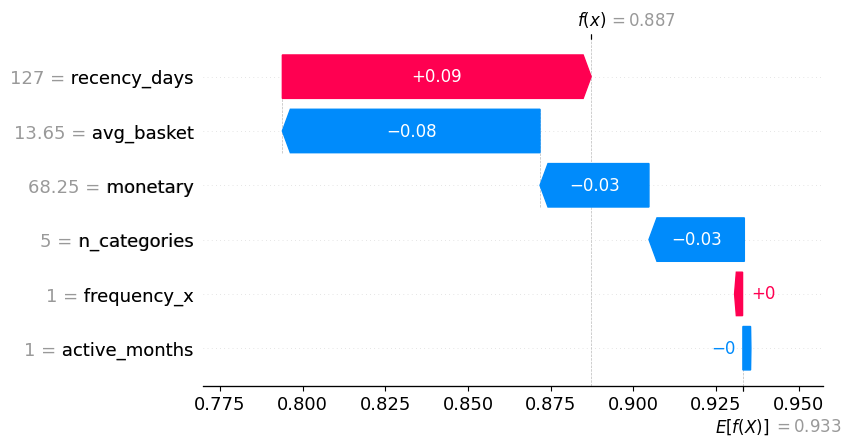

In [221]:
row_id = 0   # premier client du X_shap

selected_features = [
    "monetary",
    "avg_basket",
    "active_months",
    "frequency_x",
    "n_categories",
    "recency_days"
]

feat_idx = [X_shap.columns.get_loc(f) for f in selected_features]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_id, feat_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[row_id][selected_features],
        feature_names=selected_features
    )
)

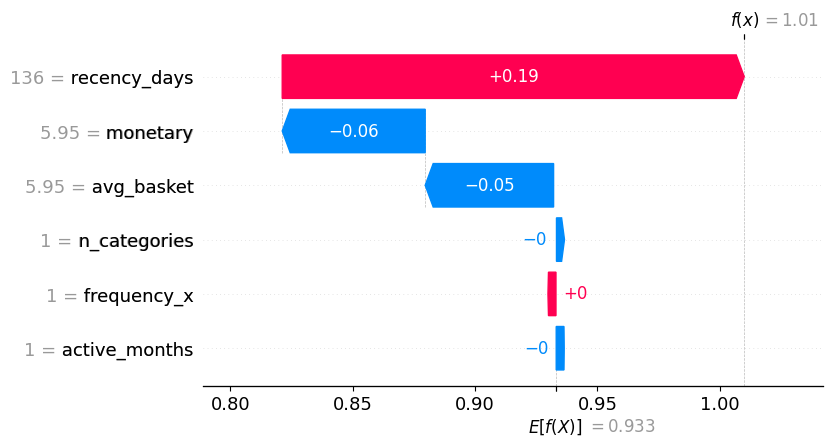

In [222]:
row_id = -1  # dernier client

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_id, feat_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[row_id][selected_features],
        feature_names=selected_features
    )
)

L’analyse locale montre que les clients à forte CLV prédite se distinguent par une fréquence d’achat élevée, un montant cumulé important et une activité récente. À l’inverse, les clients à faible CLV présentent une faible régularité et une ancienneté limitée.

In [223]:
shap_importance = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "importance": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("importance", ascending=False)
)

shap_importance.head(10)

,feature,importance
0,customer_id,1.094106
4,avg_basket,0.132671
3,monetary,0.132232
8,amount_trend,0.107667
1,recency_days,0.106201
9,tenure_days,0.090398
5,n_categories,0.033807
6,interpurchase_std,0.029224
10,first_month,0.006575
12,frequency_y,0.004648


Les variables les plus actionnables identifiées via SHAP concernent principalement la fréquence d’achat, le panier moyen et la régularité des transactions. Ces leviers peuvent être directement exploités par des actions marketing ciblées telles que des campagnes de réactivation, des offres promotionnelles personnalisées ou des stratégies de fidélisation.

## Etape5 ##

In [224]:
analysis_df = pd.DataFrame({
    "clv_real": y_test,
    "clv_pred": pred_gbr
})

In [225]:
analysis_df["clv_decile"] = pd.qcut(
    analysis_df["clv_pred"],
    q=10,
    labels=False
) + 1  # déciles 1 à 10

In [226]:
analysis_df["clv_decile"] = pd.qcut(
    analysis_df["clv_pred"],
    q=10,
    labels=False
) + 1  # déciles 1 à 10

In [227]:
analysis_df["clv_decile"].value_counts().sort_index()

clv_decile
1     13
2     12
3     12
4     14
5     11
6     12
7     13
8     12
9     12
10    13
Name: count, dtype: int64

In [228]:
analysis_df = analysis_df.merge(
    features[[
        "customer_id",
        "recency_days",
        "frequency_x",
        "monetary",
        "avg_basket",
        "active_months"
    ]],
    left_index=True,
    right_index=True,
    how="left"
)

In [229]:
decile_profile = (
    analysis_df
    .groupby("clv_decile")[[
        "clv_real",
        "recency_days",
        "frequency_x",
        "monetary",
        "avg_basket",
        "active_months"
    ]]
    .mean()
)

decile_profile

,clv_real,recency_days,frequency_x,monetary,avg_basket,active_months
clv_decile,,,,,,
1,0.000000,69.384615,1.307692,313.916154,99.154079,1.153846
2,0.303570,111.666667,1.250000,162.293333,35.144876,1.166667
3,0.000000,60.166667,1.250000,198.132500,83.529491,1.166667
4,0.000000,90.357143,1.214286,174.770000,45.919609,1.142857
5,0.000000,53.000000,1.272727,174.168182,64.444941,1.181818
6,0.299547,42.500000,1.166667,297.765000,128.935972,1.166667
7,0.000000,34.846154,1.307692,748.768462,174.647885,1.153846
8,0.697430,94.416667,1.083333,161.762500,97.751950,1.083333
9,0.309667,101.000000,1.000000,143.230000,92.864658,1.000000


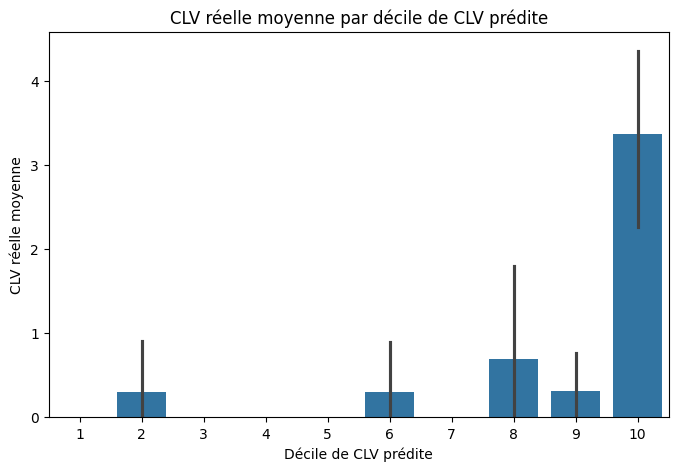

In [230]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=analysis_df,
    x="clv_decile",
    y="clv_real"
)
plt.title("CLV réelle moyenne par décile de CLV prédite")
plt.xlabel("Décile de CLV prédite")
plt.ylabel("CLV réelle moyenne")
plt.show()

In [231]:
top_10 = analysis_df[analysis_df["clv_decile"] == 10]

In [232]:
n_clients = len(top_10)
clv_moyenne = top_10["clv_real"].mean()

In [233]:
lift = 0.15
gain_total = n_clients * clv_moyenne * lift

In [234]:
cout_total = n_clients * 2

In [235]:
roi = (gain_total - cout_total) / cout_total

In [236]:
gain_total, cout_total, roi

(np.float64(6.557086789724185), 26, np.float64(-0.7478043542413775))